## RANDOM FOREST

In [1]:

# 1. Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV, train_test_split

In [ ]:
# 2. Load Data
"""
train_df = pd.read_csv('use--filtered_data_train_processed_features_all_columns_rmb.csv')
test_df = pd.read_csv('use--filtered_data_test_processed_features_all_columns_rmb.csv')

These csv files are the result of a data cleaning and processing step, then they are renamed and put to data folder:
use--filtered_data_train_processed_features_all_columns.csv = train.csv
use--filtered_data_test_processed_features_all_columns.csv = test.csv
"""
train_path = "../data/TRAIN.csv"
test_path = "../data/TEST.csv"

train_df = pd.read_csv(train_path, encoding='latin1')
test_df = pd.read_csv(test_path, encoding='latin1')

print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")


Training set shape: (165808, 25)
Test set shape: (62733, 25)


In [25]:
# 3. Check Tran_Dt Column

print(f"\nTran_Dt unique value count: {train_df['Tran_Dt'].nunique()}")
print(f"Tran_Dt date range: {train_df['Tran_Dt'].min()} to {train_df['Tran_Dt'].max()}")



Tran_Dt unique value count: 2743
Tran_Dt date range: 2012-11-22 to 2021-06-30



Time Feature Engineering
Date range: 2012-11-22 00:00:00 to 2021-06-30 00:00:00
Year range: 2012 - 2021


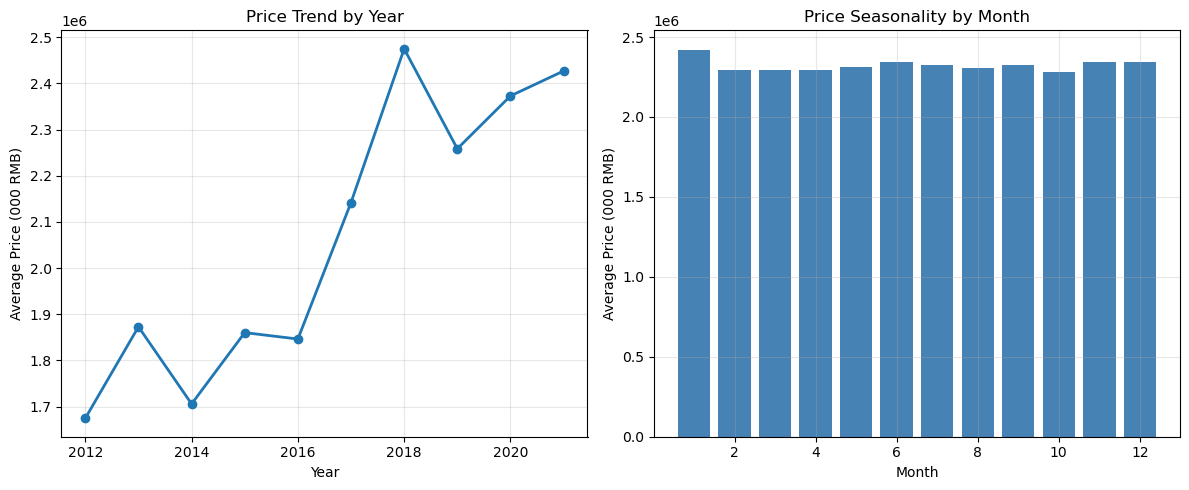

In [27]:
# 4. Time Feature Engineering (Added here!)

print("\n" + "="*60)
print("Time Feature Engineering")
print("="*60)

# Convert date format
train_df['Tran_Dt'] = pd.to_datetime(train_df['Tran_Dt'])
test_df['Tran_Dt'] = pd.to_datetime(test_df['Tran_Dt'])

# Extract time features
for df in [train_df, test_df]:
    df['Tran_Year'] = df['Tran_Dt'].dt.year
    df['Tran_Month'] = df['Tran_Dt'].dt.month
    df['Tran_Quarter'] = df['Tran_Dt'].dt.quarter
    df['Tran_Month_Sin'] = np.sin(2 * np.pi * df['Tran_Month'] / 12)
    df['Tran_Month_Cos'] = np.cos(2 * np.pi * df['Tran_Month'] / 12)

# Calculate relative year
min_year = train_df['Tran_Year'].min()
train_df['Tran_Year_Index'] = train_df['Tran_Year'] - min_year
test_df['Tran_Year_Index'] = test_df['Tran_Year'] - min_year

# Season feature
train_df['Tran_Season'] = train_df['Tran_Month'] % 12 // 3 + 1
test_df['Tran_Season'] = test_df['Tran_Month'] % 12 // 3 + 1

print(f"Date range: {train_df['Tran_Dt'].min()} to {train_df['Tran_Dt'].max()}")
print(f"Year range: {train_df['Tran_Year'].min()} - {train_df['Tran_Year'].max()}")

# Visualize price change over time
plt.figure(figsize=(12, 5))

yearly_price = train_df.groupby('Tran_Year')['Tran_Pri'].mean().reset_index()
plt.subplot(1, 2, 1)
plt.plot(yearly_price['Tran_Year'], yearly_price['Tran_Pri'], 'o-', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Average Price (000 RMB)')
plt.title('Price Trend by Year')
plt.grid(True, alpha=0.3)

monthly_price = train_df.groupby('Tran_Month')['Tran_Pri'].mean().reset_index()
plt.subplot(1, 2, 2)
plt.bar(monthly_price['Tran_Month'], monthly_price['Tran_Pri'], color='steelblue')
plt.xlabel('Month')
plt.ylabel('Average Price (000 RMB)')
plt.title('Price Seasonality by Month')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [29]:
# 5. Define Feature Columns and Target Column (Including Time Features)

target_column = 'Tran_Pri'

# Original 16 features + Building_Age
original_features = [
    'City', 'Reg', 'Dist', 'Neigh', 'Tran_Day',
    'Prop_Flo', 'Tot_Flo', 'Flo_Area', 'Build_Type',
    'Orient', 'Build_Yr_Filled', 'ReNov', 'Build_Str',
    'Elevator_Density', 'Lift', 'Total_Rooms', 'Building_Age'
]

# Time features (newly added)
time_features = [
    'Tran_Year',
    'Tran_Month', 
    'Tran_Quarter',
    'Tran_Year_Index',
    'Tran_Month_Sin',
    'Tran_Month_Cos'
]

feature_columns = original_features + time_features

print(f"\nNumber of feature variables: {len(feature_columns)}")
print(f"  - Original features: {len(original_features)}")
print(f"  - Time features: {len(time_features)}")
print(f"\nTime features: {time_features}")



Number of feature variables: 23
  - Original features: 17
  - Time features: 6

Time features: ['Tran_Year', 'Tran_Month', 'Tran_Quarter', 'Tran_Year_Index', 'Tran_Month_Sin', 'Tran_Month_Cos']


In [31]:
# 6. Feature Encoding (Handle Categorical Features)

categorical_features = train_df[feature_columns].select_dtypes(include=['object']).columns.tolist()
numerical_features = train_df[feature_columns].select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nCategorical features: {categorical_features}")
print(f"Numerical features: {numerical_features}")

# Copy data
train_processed = train_df.copy()
test_processed = test_df.copy()

# Label Encoding
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    all_values = pd.concat([train_processed[col], test_processed[col]], axis=0).astype(str).unique()
    le.fit(all_values)
    
    train_processed[col + '_encoded'] = le.transform(train_processed[col].astype(str))
    test_processed[col + '_encoded'] = le.transform(test_processed[col].astype(str))
    
    label_encoders[col] = le
    print(f"  {col}: {len(le.classes_)} categories")

# Update feature columns
feature_columns_encoded = []
for col in feature_columns:
    if col in categorical_features:
        feature_columns_encoded.append(col + '_encoded')
    else:
        feature_columns_encoded.append(col)
        


Categorical features: ['City', 'Reg', 'Dist', 'Neigh', 'Prop_Flo', 'Build_Type', 'Orient', 'ReNov', 'Build_Str', 'Lift']
Numerical features: ['Tran_Day', 'Tot_Flo', 'Flo_Area', 'Build_Yr_Filled', 'Elevator_Density', 'Total_Rooms', 'Building_Age', 'Tran_Month_Sin', 'Tran_Month_Cos']
  City: 9 categories
  Reg: 68 categories
  Dist: 414 categories
  Neigh: 14890 categories
  Prop_Flo: 4 categories
  Build_Type: 4 categories
  Orient: 144 categories
  ReNov: 4 categories
  Build_Str: 7 categories
  Lift: 2 categories


In [33]:
# 7. Prepare Training and Test Data

X_train = train_processed[feature_columns_encoded]
y_train = train_processed[target_column]
X_test = test_processed[feature_columns_encoded]
y_test = test_processed[target_column]

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")



X_train shape: (165808, 23)
X_test shape: (62733, 23)


In [ ]:
# Grid Search with Intermediate Results (Early stopping possible)


from sklearn.model_selection import ParameterGrid
import time

print("="*60)
print("Grid Search (with progress display)")
print("="*60)

# Define parameter grid
param_grid = {
    'n_estimators': [80, 100, 120],
    'max_depth': [10, 12, 14],
    'min_samples_split': [6, 8, 10],
    'min_samples_leaf': [3, 4, 5],
}

# Generate all parameter combinations
all_params = list(ParameterGrid(param_grid))
total = len(all_params)
print(f"Total parameter combinations: {total}")

# Store results
results = []

# Manual loop to see progress
for i, params in enumerate(all_params, 1):
    print(f"\n[{i}/{total}] Testing parameters: {params}")
    
    start_time = time.time()
    
    # Train model with current parameters
    rf = RandomForestRegressor(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_samples_split=params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf'],
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
    
    # Use cross-validation (simplified here, using validation set instead)
    from sklearn.model_selection import cross_val_score
    cv_scores = cross_val_score(rf, X_train, y_train, cv=3, scoring='r2')
    
    elapsed = time.time() - start_time
    
    results.append({
        'n_estimators': params['n_estimators'],
        'max_depth': params['max_depth'],
        'min_samples_split': params['min_samples_split'],
        'min_samples_leaf': params['min_samples_leaf'],
        'mean_r2': cv_scores.mean(),
        'std_r2': cv_scores.std(),
        'time': elapsed
    })
    
    print(f"  Mean R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"  Time elapsed: {elapsed:.1f} seconds")
    
    # Display current best
    current_best = max(results, key=lambda x: x['mean_r2'])
    print(f"  Current best R²: {current_best['mean_r2']:.4f} - {current_best}")

# Find best parameters
results_df = pd.DataFrame(results)
best_result = results_df.loc[results_df['mean_r2'].idxmax()]

print("\n" + "="*60)
print("Grid Search Complete!")
print("="*60)
print(f"Best parameters:")
print(f"  n_estimators: {best_result['n_estimators']}")
print(f"  max_depth: {best_result['max_depth']}")
print(f"  min_samples_split: {best_result['min_samples_split']}")
print(f"  min_samples_leaf: {best_result['min_samples_leaf']}")
print(f"  Mean R²: {best_result['mean_r2']:.4f}")

# Display all results sorted
print("\nAll results sorted (by R² descending):")
results_df_sorted = results_df.sort_values('mean_r2', ascending=False)
print(results_df_sorted.head(10).to_string(index=False))


In [35]:
# 8. Final Optimized Random Forest Model

print("\n" + "="*60)
print("Final Optimized Random Forest Model (Including Time Features)")
print("="*60)

rf_final = RandomForestRegressor(
    n_estimators=120,
    max_depth=14,
    min_samples_split=8,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

print("Starting training...")
rf_final.fit(X_train, y_train)
print("Training complete!")

# Prediction and evaluation
y_train_pred = rf_final.predict(X_train)
y_test_pred = rf_final.predict(X_test)

# Evaluation function
def evaluate_model(y_true, y_pred, dataset_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{dataset_name} Evaluation Results:")
    print(f"  R²: {r2:.4f}")
    print(f"  MAE: {mae:.2f} (approx {mae/1000:.1f}K RMB)")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    
    return {'R2': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

print("\n" + "="*60)
print("Final Model Evaluation Results (Including Time Features)")
print("="*60)

train_metrics = evaluate_model(y_train, y_train_pred, "Training Set")
test_metrics = evaluate_model(y_test, y_test_pred, "Test Set")

overfit_gap = train_metrics['R2'] - test_metrics['R2']
print(f"\nOverfitting gap: {overfit_gap:.4f}")



Final Optimized Random Forest Model (Including Time Features)
Starting training...
Training complete!

Final Model Evaluation Results (Including Time Features)

Training Set Evaluation Results:
  R²: 0.8134
  MAE: 438681.97 (approx 438.7K RMB)
  RMSE: 703201.01
  MAPE: 23.44%

Test Set Evaluation Results:
  R²: 0.6826
  MAE: 600272.06 (approx 600.3K RMB)
  RMSE: 1092369.82
  MAPE: 31.95%

Overfitting gap: 0.1308



Feature Importance Ranking (Top 15):
         feature  importance
        Flo_Area    0.314183
     Total_Rooms    0.122265
            City    0.098239
             Reg    0.093466
Elevator_Density    0.071951
            Dist    0.060959
         Tot_Flo    0.054774
           ReNov    0.027635
           Neigh    0.021912
 Tran_Year_Index    0.020330
       Tran_Year    0.019861
    Building_Age    0.015658
 Build_Yr_Filled    0.015648
        Tran_Day    0.015341
       Build_Str    0.010925


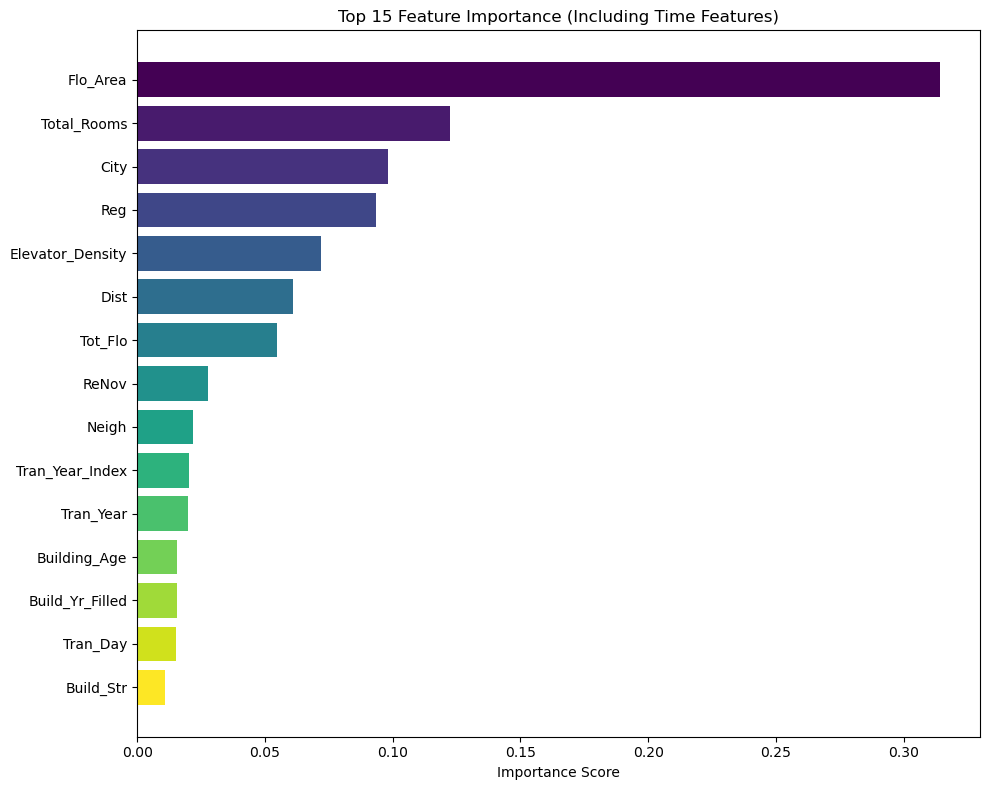

In [37]:
# 9. Feature Importance Analysis (Check Time Feature Importance)

feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_final.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance Ranking (Top 15):")
print(feature_importance.head(15).to_string(index=False))

# Visualization
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
bars = plt.barh(range(len(top_features)), top_features['importance'].values, color=colors)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importance (Including Time Features)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [39]:
# 10. Cross-Validation

print("\n5-Fold Cross-Validation:")
cv_scores = cross_val_score(rf_final, X_train, y_train, cv=5, scoring='r2')
print(f"Cross-validation R² scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")



5-Fold Cross-Validation:
Cross-validation R² scores: [0.37335841 0.76948957 0.75135399 0.71653376 0.68278572]
Mean R²: 0.6587 (+/- 0.2915)


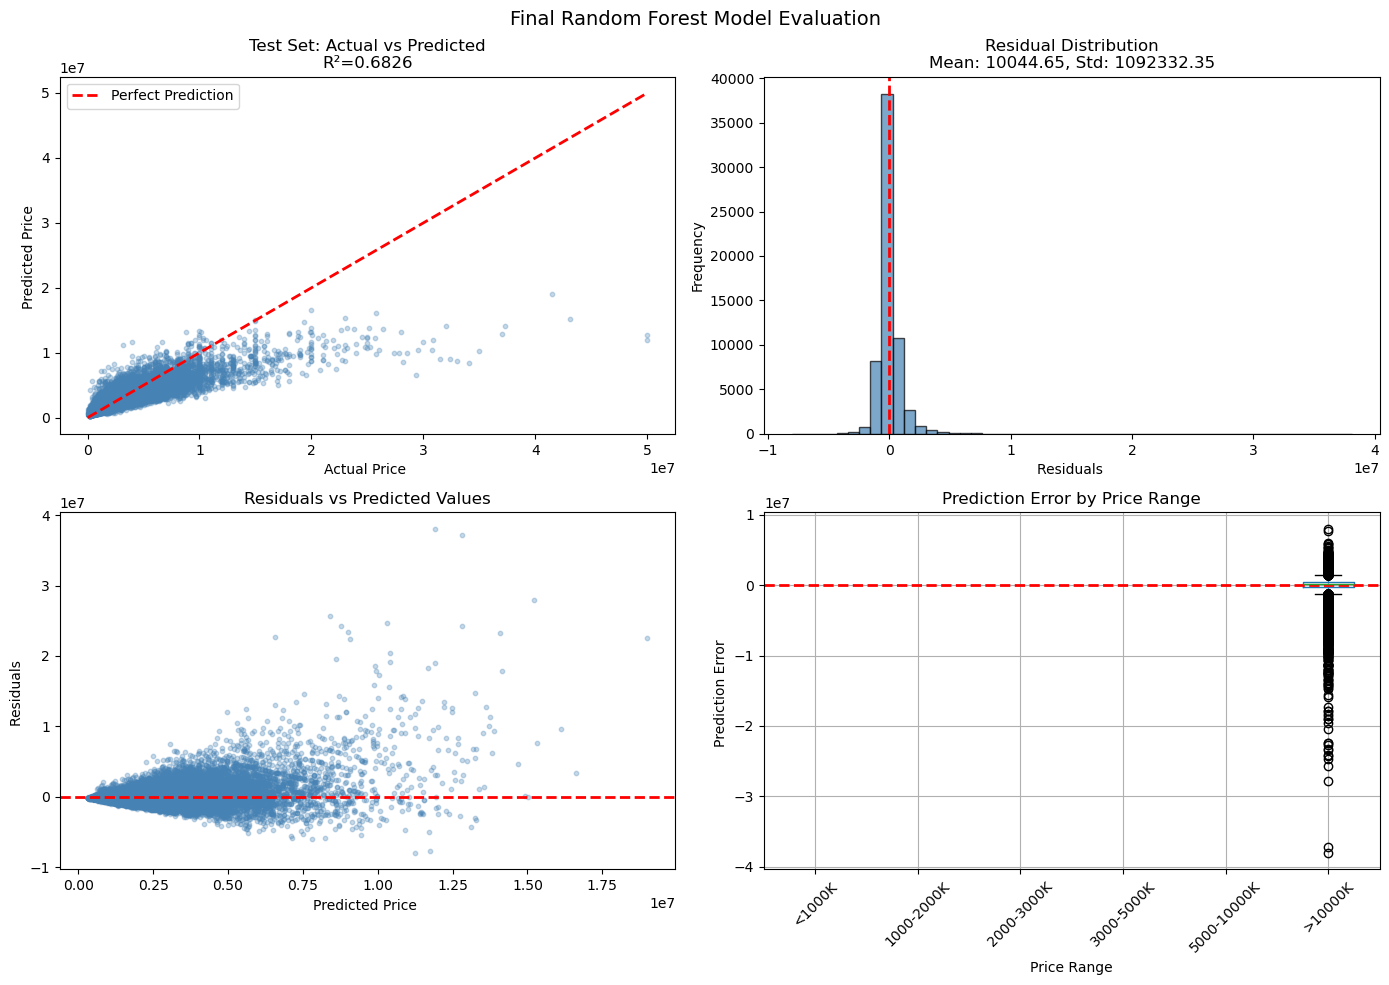

In [41]:
# 11. Prediction Results Visualization

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 11.1 Test Set: Actual vs Predicted Scatter Plot
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.3, s=10, color='steelblue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Price ')
axes[0, 0].set_ylabel('Predicted Price ')
axes[0, 0].set_title(f'Test Set: Actual vs Predicted\nR²={test_metrics["R2"]:.4f}')
axes[0, 0].legend()

# 11.2 Residual Distribution Histogram
residuals = y_test - y_test_pred
axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Residuals ')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'Residual Distribution\nMean: {residuals.mean():.2f}, Std: {residuals.std():.2f}')

# 11.3 Residuals vs Predicted Values
axes[1, 0].scatter(y_test_pred, residuals, alpha=0.3, s=10, color='steelblue')
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Price ')
axes[1, 0].set_ylabel('Residuals ')
axes[1, 0].set_title('Residuals vs Predicted Values')

# 11.4 Prediction Error by Price Range
price_bins = pd.cut(y_test, bins=[0, 1000, 2000, 3000, 5000, 10000, float('inf')], 
                     labels=['<1000K', '1000-2000K', '2000-3000K', '3000-5000K', '5000-10000K', '>10000K'])
error_by_bin = pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred, 'Price_Bin': price_bins})
error_by_bin['Error'] = error_by_bin['Predicted'] - error_by_bin['Actual']

# Box plot
error_by_bin.boxplot(column='Error', by='Price_Bin', ax=axes[1, 1])
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Price Range')
axes[1, 1].set_ylabel('Prediction Error ')
axes[1, 1].set_title('Prediction Error by Price Range')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('Final Random Forest Model Evaluation', fontsize=14)
plt.tight_layout()
plt.show()